# Computational Methods TP3

In [5]:
from lib_installer import check_and_install_libraries

check_and_install_libraries()

Checking libraries...

✓ numpy is installed
✓ matplotlib is installed
✓ pandas is installed

All libraries ready!


## Section 3

In [47]:
import numpy as np
import matplotlib.pyplot as plt

# Import the master execution function from our local 'main.py' module.
# run_base_case encapsulates the entire pipeline required for Section 3:
# 1. Building Efficient Portfolios (Data)
# 2. Constructing the Wealth Grid (State Space)
# 3. Running Dynamic Programming (In-Sample Solution)
# 4. Running Monte Carlo Simulation (Out-of-Sample Validation)
from main import run_base_case


In [48]:
# --- Execute Base Case Analysis (Section 3) ---
# This calls the main wrapper function which orchestrates the entire pipeline:
# 1. Construction of Efficient Portfolios
# 2. Grid Generation (shifted for G=200)
# 3. Transition Probability Calculation & DP Solver (Backward Induction)
# 4. Monte Carlo Simulation (Forward Testing)

w0, G, T, w_grid, V, policy, W_paths, p_in, p_oos = run_base_case()

# Print the key results to verify against the Das et al. paper
# The paper reports 0.669. Our improved grid should yield approx 0.670.
print(f"In-sample success probability  : {p_in:.4f}")
print(f"Out-of-sample success probability: {p_oos:.4f}")


In-sample success probability  : 0.6703
Out-of-sample success probability: 0.6698


### Value function at a few times (Section 3.1)
Value function V_t(W) at selected times for three time points: start, middle, and horizon.

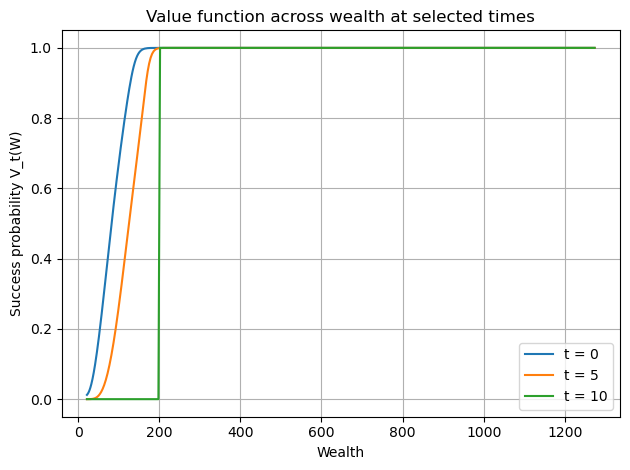

In [49]:
import os
import matplotlib.pyplot as plt

# Ensure output directory exists
os.makedirs("plots", exist_ok=True)

# --- Figure 1: Value Function Evolution ---
# This plot illustrates how the probability of success V_t(W) changes 
# as a function of wealth at different points in time.
plt.figure()

# Select representative times to show the progression:
# t=0 (Start), t=5 (Midpoint), t=10 (Maturity)
times = [0, T // 2, T]

for t in times:
    # Plot the value function for time t across the entire wealth grid
    plt.plot(w_grid, V[t, :], label=f"t = {t}")

# Formatting
plt.xlabel("Wealth")
plt.ylabel("Success probability V_t(W)")
plt.title("Value function across wealth at selected times")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Save to file for LaTeX
plt.savefig("plots/value_function_plot.png", dpi=300)

plt.show()


### Optimal policy heatmap (Section 3.2)
This shows which portfolio index is chosen depending on time and wealth.

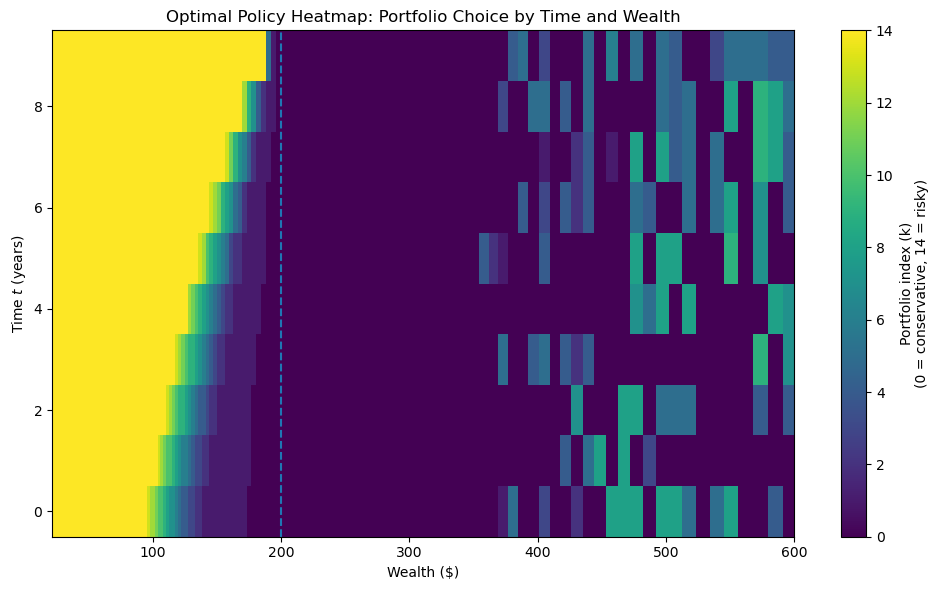

In [50]:
import os
import matplotlib.pyplot as plt
import numpy as np

# Ensure output directory exists
os.makedirs("plots", exist_ok=True)

# --- Figure 2: Optimal Policy Heatmap ---

# 1. Prepare the Grid for Plotting
# We use meshgrid because w_grid is logarithmically spaced.
# Passing explicit W_mesh coordinates to pcolormesh ensures the
# x-axis represents actual dollar wealth, not just grid indices.
time_steps = np.arange(T)  # 0..9
W_mesh, T_mesh = np.meshgrid(w_grid, time_steps)

plt.figure(figsize=(10, 6))

# 2. Generate the Heatmap
# 'viridis' maps low values (0/conservative) to purple and high values (14/risky) to yellow.
c = plt.pcolormesh(
    W_mesh,
    T_mesh,
    policy,
    cmap="viridis",
    shading="auto"
)

# 4. Visual Reference for the Goal
# The dashed line at G=200 shows where the "switch" to safety should happen.
plt.colorbar(c, label="Portfolio index (k)\n(0 = conservative, 14 = risky)")
plt.xlabel("Wealth ($)")
plt.ylabel("Time $t$ (years)")
plt.title("Optimal Policy Heatmap: Portfolio Choice by Time and Wealth")

# 5. Zoom on the Relevant Region
# We limit x-axis to 600 because beyond this point, the investor is safe
# and the policy is trivially conservative (purple).
plt.axvline(G, linestyle="--")
plt.xlim(w_grid[0], 600)

plt.tight_layout()

# Save to file for LaTeX
plt.savefig("plots/policy_heatmap.png", dpi=300)

plt.show()


### 3.3

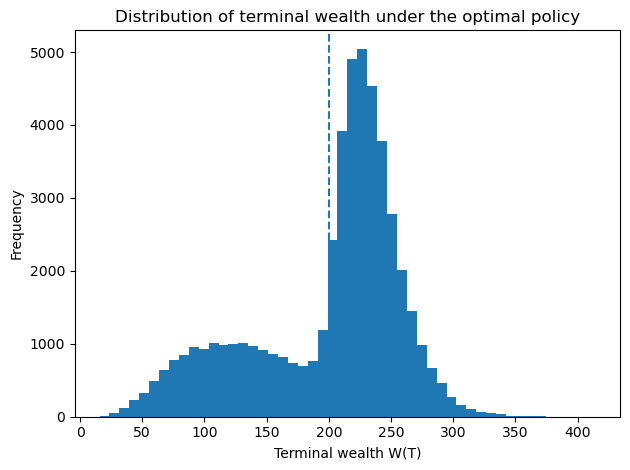

Quantiles of W(T):
10%: 100.23
25%: 162.73
50%: 218.79
75%: 239.57
90%: 259.58
Fraction of paths above G = 200.0: 0.6698


In [51]:
import os
import matplotlib.pyplot as plt
import numpy as np

# Ensure the output directory exists for saving report figures
os.makedirs("plots", exist_ok=True)

# --- Analysis for Section 3.3: Terminal Wealth Distribution ---

# 1. Extract Terminal Wealth
# W_paths has shape (n_paths, T+1). We take the last column (time T).
W_T = W_paths[:, -1]

# 2. Generate Histogram (Figure 3 in Report)
plt.figure()
plt.hist(W_T, bins=50)
plt.axvline(G, linestyle="--")  # goal line
plt.xlabel("Terminal wealth W(T)")
plt.ylabel("Frequency")
plt.title("Distribution of terminal wealth under the optimal policy")
plt.tight_layout()

# Save to file for LaTeX
plt.savefig("plots/terminal_wealth_hist.png", dpi=300)

plt.show()

# 3. Calculate Summary Statistics for Report Text
# These quantiles are cited in Section 3.3 to describe the "wide spread of outcomes"
q = np.quantile(W_T, [0.10, 0.25, 0.50, 0.75, 0.90])
print("Quantiles of W(T):")
for level, value in zip([0.10, 0.25, 0.50, 0.75, 0.90], q):
    print(f"{level:.0%}: {value:.2f}")

# 4. Calculate Out-of-Sample Success Probability
# This number validates the In-Sample DP result (robustness check)
print(f"Fraction of paths above G = {G}: {(W_T >= G).mean():.4f}")


Shapes: V = (11, 200) w_flat = (200,)
Sub-shapes: V_sub = (11, 88) w_sub = (88,)


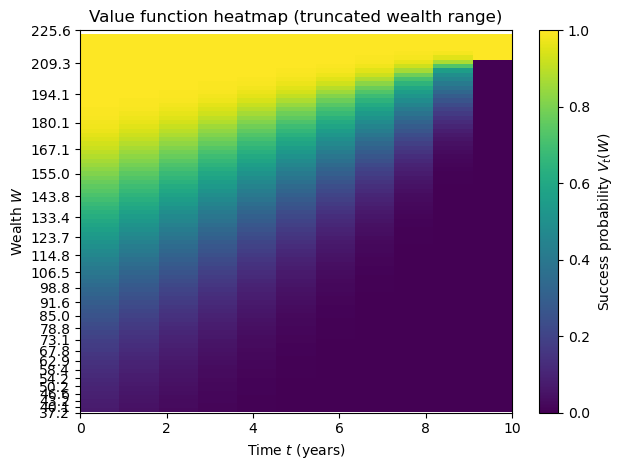

In [52]:
import numpy as np
import matplotlib.pyplot as plt

# We assume you've already done:
# w0, G, T, w_grid, V, policy, W_paths, p_in, p_oos = run_base_case()

# Make sure V and w_grid are proper numpy arrays
V = np.array(V)
w_flat = np.array(w_grid).reshape(-1)   # shape (nw,)

print("Shapes:", "V =", V.shape, "w_flat =", w_flat.shape)

# 1. Select the wealth range [37, 226] like in the paper
w_min_disp = 37.0
w_max_disp = 226.0

mask = (w_flat >= w_min_disp) & (w_flat <= w_max_disp)
idx = np.where(mask)[0]                 # integer indices of wealth nodes in range

w_sub = w_flat[idx]                     # wealth nodes in displayed range
V_sub = V[:, idx]                       # shape (T+1, n_sub)

print("Sub-shapes:", "V_sub =", V_sub.shape, "w_sub =", w_sub.shape)

# 2. Build the heatmap: x = time, y = wealth, color = V_t(W)
plt.figure()

# V_sub has shape (T+1, n_sub); we want rows=wealth, cols=time -> transpose
plt.imshow(
    V_sub.T,
    aspect="auto",
    origin="lower",
    extent=[0, T, w_sub[0], w_sub[-1]]
)

cbar = plt.colorbar()
cbar.set_label("Success probability $V_t(W)$")

plt.xlabel("Time $t$ (years)")
plt.ylabel("Wealth $W$")

plt.title("Value function heatmap (truncated wealth range)")

# Optional: mimic the paper's y-ticks
yticks = [37.2, 40.1, 43.2, 46.6, 50.2, 54.2, 58.4, 62.9, 67.8,
          73.1, 78.8, 85.0, 91.6, 98.8, 106.5, 114.8, 123.7,
          133.4, 143.8, 155.0, 167.1, 180.1, 194.1, 209.3, 225.6]
plt.yticks(yticks)

plt.tight_layout()
plt.show()


## Section 4

In [53]:
import numpy as np
import pandas as pd

from build_portfolios import build_portfolios
from experiments import experiment_vary_nw, experiment_vary_ns


### 4.1 Vary nw

In [54]:
# --- Experiment 1: Sensitivity to Grid Density (nw) ---
# We test how the resolution of the grid affects the precision of the solution.
# Low nw (coarse grid) = faster but higher interpolation error.
# High nw (fine grid) = slower but better convergence between In-Sample and OOS.

# Build the 15 efficient portfolios once
vmu, vsi, weights, index_means, cov_matrix = build_portfolios()

# Use a fixed RNG so results are comparable across experiments
rng = np.random.default_rng(123)

nw_list = [50, 100, 200, 400]
ns = 3       # Keep the range fixed at the Base Case level
n_paths_oos = 20000  # fewer than 50k to keep runtime reasonable

# Run the experiment
results_nw = experiment_vary_nw(
    vmu, vsi,
    nw_list=nw_list,
    ns=ns,
    n_paths_oos=n_paths_oos,
    rng=rng
)

# Build a DataFrame to display the results (Table 1)
rows = []
for res in results_nw:
    rows.append({
        "nw": res["nw"],
        "p_in": res["p_success_in_sample"],
        "p_oos": res["p_success_oos"],
        "abs_diff": abs(res["p_success_in_sample"] - res["p_success_oos"]),
        "dp_time_sec": res["dp_time_sec"],
        "sim_time_sec": res["sim_time_sec"],
    })

df_nw = pd.DataFrame(rows)
df_nw


,nw,p_in,p_oos,abs_diff,dp_time_sec,sim_time_sec
0,50,0.670819,0.66345,0.007369,0.006122,0.011950
1,100,0.671454,0.67625,0.004796,0.016198,0.014641
2,200,0.670340,0.67210,0.001760,0.042989,0.011295
3,400,0.670127,0.67210,0.001973,0.064441,0.013829


### 4.1 Vary ns

In [55]:
# --- Experiment 2: Sensitivity to Grid Range (ns) ---
# We test how the width of the grid affects the accuracy of the solution.
# Low ns (e.g., 1) cuts off tails; High ns (e.g., 4) captures extreme events but might waste grid points.
ns_list = [1, 2, 3, 4]
nw = 200
n_paths_oos = 20000

# Run the experiment (looping over ns_list)
results_ns = experiment_vary_ns(
    vmu, vsi,
    ns_list=ns_list,
    w0=100.0, G=200.0, T=10,
    nw=nw,
    n_paths_oos=n_paths_oos,
    rng=rng
)

# Process results into a structured format for the report table
rows = []
for res in results_ns:
    rows.append({
        "ns": res["ns"],
        "p_in": res["p_success_in_sample"],
        "p_oos": res["p_success_oos"],
        "abs_diff": abs(res["p_success_in_sample"] - res["p_success_oos"]),
        "dp_time_sec": res["dp_time_sec"],
        "sim_time_sec": res["sim_time_sec"],
    })

# Create DataFrame to display Table 2
df_ns = pd.DataFrame(rows)
df_ns


,ns,p_in,p_oos,abs_diff,dp_time_sec,sim_time_sec
0,1,0.722389,0.66440,0.057989,0.027823,0.012991
1,2,0.670338,0.67315,0.002812,0.025751,0.011784
2,3,0.670340,0.67645,0.006110,0.025088,0.011428
3,4,0.670529,0.67225,0.001721,0.028913,0.011374
